In [907]:
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import ta

In [908]:
df = pd.read_csv("NVDA.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.reset_index(drop=True)
df["Date"].tail(10)

6548   2025-02-03
6549   2025-02-04
6550   2025-02-05
6551   2025-02-06
6552   2025-02-07
6553   2025-02-10
6554   2025-02-11
6555   2025-02-12
6556   2025-02-13
6557   2025-02-14
Name: Date, dtype: datetime64[us]

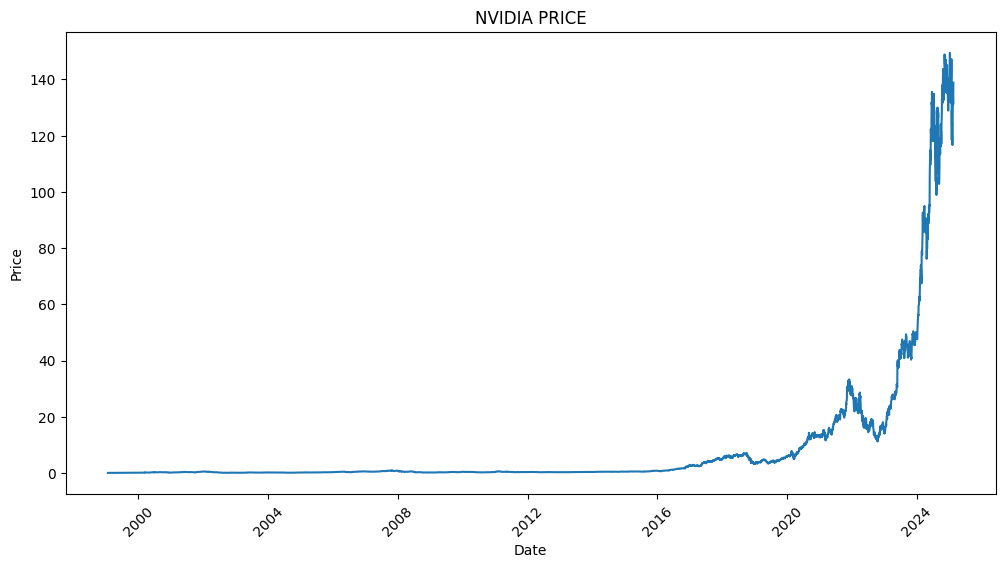

In [909]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Adj Close"])
plt.title("NVIDIA PRICE")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

In [910]:
df_recent = df.tail(500)
fig = go.Figure(data=[go.Candlestick(
    x=df_recent["Date"],
    open=df_recent["Open"],
    high=df_recent["High"],
    low=df_recent["Low"],
    close=df_recent["Close"]
)])

fig.update_layout(
    title="NVIDIA Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price"
)

fig.show()

In [911]:
def compute_forward_return(df, horizon):
    """
    Compute forward percentage return over given horizon.
    
    Parameters
    ----------
    df : pandas DataFrame
    horizon : int (number of trading days)
    
    Returns
    -------
    pandas Series
    """
    return df["Adj Close"].pct_change(horizon).shift(-horizon)
df["fwd_return_20"] = compute_forward_return(df, 20)
df["fwd_return_30"] = compute_forward_return(df, 30)
df["fwd_return_14"] = compute_forward_return(df, 14)



In [912]:
def label_events(forward_returns, threshold):

    labels = np.full(len(forward_returns), np.nan)

    labels[forward_returns >= threshold] = 1
    labels[forward_returns <= -threshold] = -1

    labels[(forward_returns < threshold) & 
           (forward_returns > -threshold)] = 0

    return labels
df["event_20D_10%"] = label_events(df["fwd_return_20"], 0.10)
df["event_30D_10%"] = label_events(df["fwd_return_30"], 0.10)
df["event_14D_10%"] = label_events(df["fwd_return_14"], 0.10)
df["event_20D_15%"] = label_events(df["fwd_return_20"], 0.15)


df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           6558 non-null   datetime64[us]
 1   Adj Close      6558 non-null   float64       
 2   Close          6558 non-null   float64       
 3   High           6558 non-null   float64       
 4   Low            6558 non-null   float64       
 5   Open           6558 non-null   float64       
 6   Volume         6558 non-null   int64         
 7   fwd_return_20  6538 non-null   float64       
 8   fwd_return_30  6528 non-null   float64       
 9   fwd_return_14  6544 non-null   float64       
 10  event_20D_10%  6538 non-null   float64       
 11  event_30D_10%  6528 non-null   float64       
 12  event_14D_10%  6544 non-null   float64       
 13  event_20D_15%  6538 non-null   float64       
dtypes: datetime64[us](1), float64(12), int64(1)
memory usage: 717.4 KB


Date              0
Adj Close         0
Close             0
High              0
Low               0
Open              0
Volume            0
fwd_return_20    20
fwd_return_30    30
fwd_return_14    14
event_20D_10%    20
event_30D_10%    30
event_14D_10%    14
event_20D_15%    20
dtype: int64

In [913]:
#Binary classifier 0 vs 1
def label_events_binary(forward_returns, threshold):
    labels = np.full(len(forward_returns), np.nan)
    
    # Negative event (crash)
    labels[forward_returns <= -threshold] = 0
    
    # Everything else
    labels[forward_returns > -threshold] = 1
    
    return labels
df["event_binary"] = label_events_binary(df["fwd_return_20"], 0)
df["event_binary"] .value_counts(normalize=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           6558 non-null   datetime64[us]
 1   Adj Close      6558 non-null   float64       
 2   Close          6558 non-null   float64       
 3   High           6558 non-null   float64       
 4   Low            6558 non-null   float64       
 5   Open           6558 non-null   float64       
 6   Volume         6558 non-null   int64         
 7   fwd_return_20  6538 non-null   float64       
 8   fwd_return_30  6528 non-null   float64       
 9   fwd_return_14  6544 non-null   float64       
 10  event_20D_10%  6538 non-null   float64       
 11  event_30D_10%  6528 non-null   float64       
 12  event_14D_10%  6544 non-null   float64       
 13  event_20D_15%  6538 non-null   float64       
 14  event_binary   6538 non-null   float64       
dtypes: datetime64[us](1), float64(13

In [914]:
def event_statistics(forward_returns, threshold):
    
    up = (forward_returns > threshold).sum()
    down = (forward_returns <= -threshold).sum()
    
    total = len(forward_returns.dropna())
    
    print("Threshold:", threshold)
    print("Positive events:", up/total)
    print("Negative events:", down/total)
    print("Total events:", up + down)
    print("events + non-events:", total)
    print("Event frequency:", (up + down)/total)
event_statistics(df["fwd_return_20"], 0)    

Threshold: 0
Positive events: 0.5894769042520649
Negative events: 0.41052309574793516
Total events: 6538
events + non-events: 6538
Event frequency: 1.0


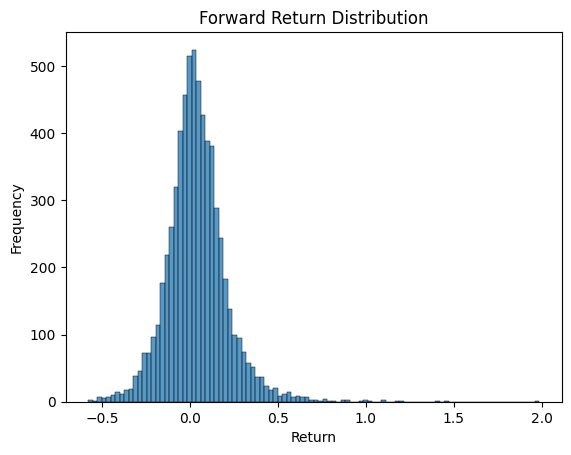

In [915]:
def plot_return_distribution(forward_returns):
    
    sns.histplot(forward_returns.dropna(), bins=100)
    
    plt.title("Forward Return Distribution")
    plt.xlabel("Return")
    plt.ylabel("Frequency")
    
    plt.show()
plot_return_distribution(df["fwd_return_20"])    

In [916]:
#Indicators
#Trend Indicators

# Moving averages
df["sma_20"] = ta.trend.SMAIndicator(df["Adj Close"], window=20).sma_indicator()
df["sma_50"] = ta.trend.SMAIndicator(df["Adj Close"], window=50).sma_indicator()

df["ema_20"] = ta.trend.EMAIndicator(df["Adj Close"], window=20).ema_indicator()
df["ema_50"] = ta.trend.EMAIndicator(df["Adj Close"], window=50).ema_indicator()

# MACD
macd = ta.trend.MACD(df["Adj Close"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

# ADX (trend strength)
adx = ta.trend.ADXIndicator(df["High"], df["Low"], df["Close"])
df["adx"] = adx.adx()

#Momentum Indicators

# RSI
df["rsi"] = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()

# Stochastic oscillator
stoch = ta.momentum.StochasticOscillator(df["High"], df["Low"], df["Close"])
df["stoch_k"] = stoch.stoch()
df["stoch_d"] = stoch.stoch_signal()

# Williams %R
df["williams_r"] = ta.momentum.WilliamsRIndicator(
    df["High"], df["Low"], df["Close"]
).williams_r()

# Rate of change
df["roc"] = ta.momentum.ROCIndicator(df["Adj Close"], window=12).roc()

#Volatility Indicators

# Average True Range
df["atr"] = ta.volatility.AverageTrueRange(
    df["High"], df["Low"], df["Close"]
).average_true_range()

# Bollinger Bands
bb = ta.volatility.BollingerBands(df["Adj Close"], window=20)

df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_width"] = bb.bollinger_wband()

# Rolling volatility
df["volatility_10"] = df["Adj Close"].pct_change().rolling(10).std()
df["volatility_20"] = df["Adj Close"].pct_change().rolling(20).std()

#Volume Indicators
# On Balance Volume
df["obv"] = ta.volume.OnBalanceVolumeIndicator(
    df["Close"], df["Volume"]
).on_balance_volume()

# Accumulation Distribution Index
df["adi"] = ta.volume.AccDistIndexIndicator(
    df["High"], df["Low"], df["Close"], df["Volume"]
).acc_dist_index()

# Chaikin Money Flow
df["cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
    df["High"], df["Low"], df["Close"], df["Volume"]
).chaikin_money_flow()

# Volume moving average
df["volume_ma20"] = df["Volume"].rolling(20).mean()

# Volume change
df["volume_change"] = df["Volume"].pct_change()

#Price based features

# Daily return
df["return_1d"] = df["Adj Close"].pct_change()

# 5 day return
df["return_5d"] = df["Adj Close"].pct_change(5)

# High-Low range
df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]

# Close-Open return
df["co_return"] = (df["Close"] - df["Open"]) / df["Open"]

# Gap return
df["gap_return"] = (df["Open"] - df["Close"].shift(1)) / df["Close"].shift(1)

#Trend distance features

df["price_sma20_ratio"] = df["Adj Close"] / df["sma_20"]
df["price_sma50_ratio"] = df["Adj Close"] / df["sma_50"]

df["ema_diff"] = df["ema_20"] - df["ema_50"]

df.isna().sum()
df = df.dropna()
df = df.drop(columns=[
"event_20D_10%",
"event_30D_10%",
"event_14D_10%",
"fwd_return_30",
"fwd_return_14"
])
df["event_20D_15%"] = df["event_20D_15%"].astype(int)
df = df.rename(columns={"event_20D_15%": "event"})
df.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume,fwd_return_20,event,event_binary,...,volume_ma20,volume_change,return_1d,return_5d,hl_range,co_return,gap_return,price_sma20_ratio,price_sma50_ratio,ema_diff
49,1999-04-05,0.037973,0.041406,0.043229,0.041146,0.042188,98640000,-0.075472,0,0.0,...,89932800.0,2.241325,-0.030486,-0.050756,0.050307,-0.018536,-0.012176,0.964361,0.971936,1.092124e-04
50,1999-04-06,0.037018,0.040365,0.041927,0.039583,0.041797,69696000,-0.103233,0,0.0,...,89623200.0,-0.293431,-0.025142,-0.101443,0.058070,-0.034261,0.009443,0.944699,0.947789,-1.509277e-05
51,1999-04-07,0.040122,0.043750,0.044010,0.040365,0.040625,89280000,-0.154765,-1,0.0,...,86928000.0,0.280992,0.083860,0.063287,0.083314,0.076923,0.006441,1.026581,1.028025,5.081969e-05
52,1999-04-08,0.040839,0.044531,0.045833,0.043490,0.044010,130128000,-0.185668,-1,0.0,...,81667200.0,0.457527,0.017851,0.011838,0.052615,0.011838,0.005943,1.045705,1.045034,1.480522e-04
53,1999-04-09,0.040122,0.043750,0.044792,0.043490,0.044792,48624000,-0.166674,-1,0.0,...,81384000.0,-0.626337,-0.017538,0.024398,0.029760,-0.023263,0.005861,1.026737,1.025703,1.918957e-04
54,1999-04-12,0.038451,0.041927,0.043229,0.041146,0.043229,33312000,-0.130441,0,0.0,...,78511200.0,-0.314906,-0.041668,0.012582,0.049682,-0.030119,-0.011909,0.984557,0.982784,1.356309e-04
55,1999-04-13,0.036898,0.040234,0.042708,0.039583,0.042708,36144000,-0.045310,0,0.0,...,74877600.0,0.085014,-0.040380,-0.003245,0.077671,-0.057928,0.018628,0.949300,0.942811,-7.674226e-07
56,1999-04-14,0.035824,0.039063,0.041016,0.039063,0.040104,48288000,0.013312,0,1.0,...,73334400.0,0.335989,-0.029105,-0.107131,0.049996,-0.025958,-0.003231,0.925795,0.915930,-1.794958e-04
57,1999-04-15,0.036779,0.040104,0.040104,0.039063,0.040104,35856000,-0.012991,0,0.0,...,72559200.0,-0.257455,0.026649,-0.099414,0.025958,0.000000,0.026649,0.953852,0.939077,-2.807069e-04
58,1999-04-16,0.037973,0.041406,0.042057,0.039844,0.039844,38928000,-0.094334,0,0.0,...,72189600.0,0.085676,0.032466,-0.053577,0.053446,0.039203,-0.006483,0.987420,0.968031,-3.007455e-04


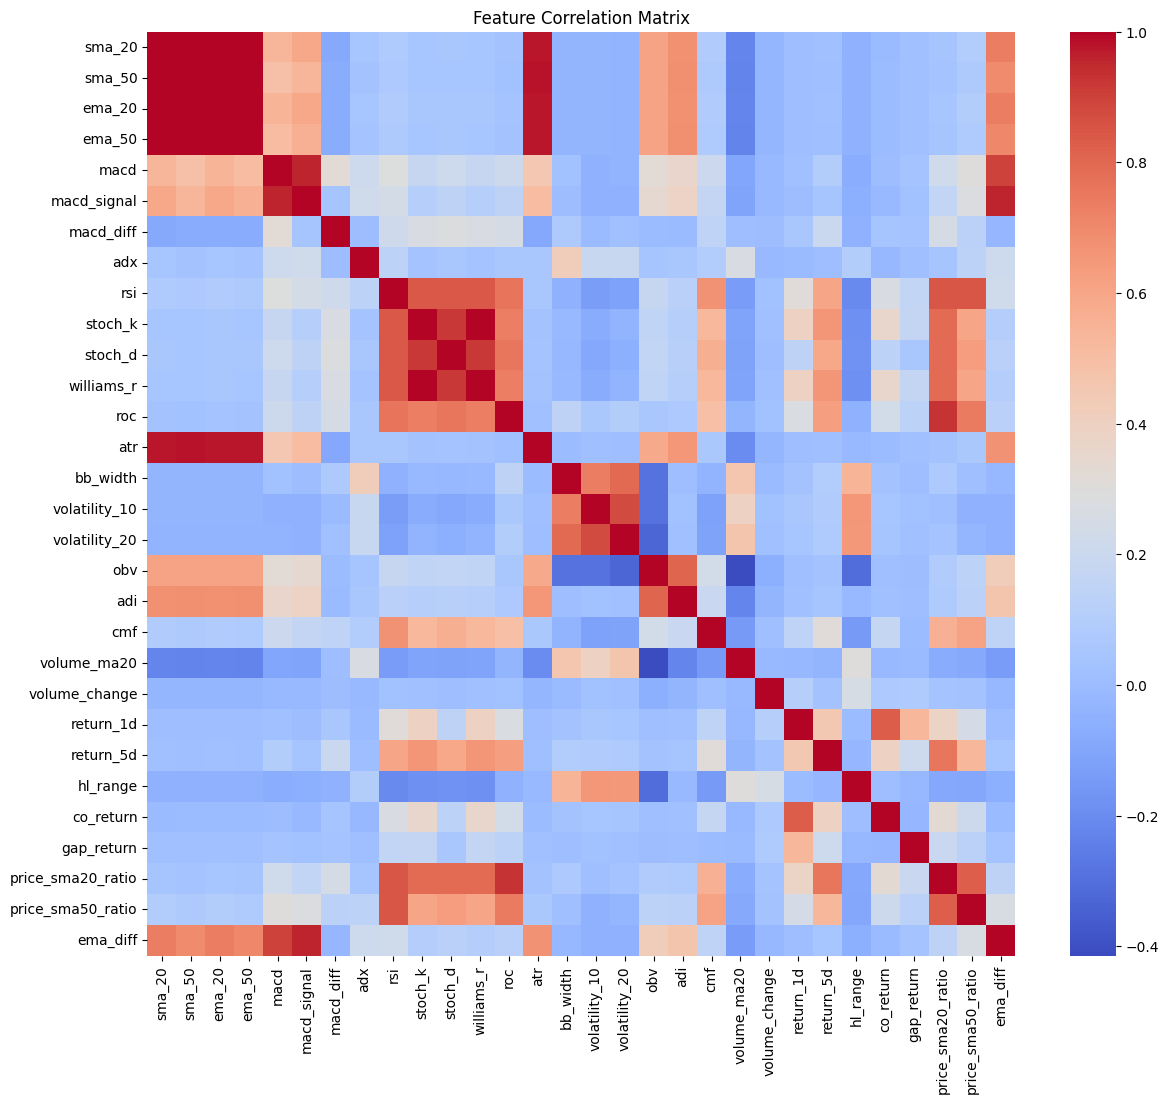

In [917]:
features = [
"sma_20","sma_50","ema_20","ema_50",
"macd","macd_signal","macd_diff",
"adx",
"rsi","stoch_k","stoch_d","williams_r","roc",
"atr","bb_width","volatility_10","volatility_20",
"obv","adi","cmf","volume_ma20","volume_change",
"return_1d","return_5d","hl_range","co_return","gap_return",
"price_sma20_ratio","price_sma50_ratio","ema_diff"
]
X = df[features]
y = df["event"]

import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [918]:
y_dir = df["event_binary"]
print(y_dir.head())
X_dir = df[features]
print(X_dir.describe())


49    0.0
50    0.0
51    0.0
52    0.0
53    0.0
Name: event_binary, dtype: float64
            sma_20       sma_50       ema_20       ema_50         macd  \
count  6479.000000  6479.000000  6479.000000  6479.000000  6479.000000   
mean      8.057631     7.733158     8.056189     7.741221     0.148929   
std      21.900678    20.890854    21.870615    20.874742     0.840862   
min       0.032779     0.033630     0.032943     0.034015    -5.167070   
25%       0.259413     0.259595     0.257543     0.259850    -0.005097   
50%       0.436075     0.436049     0.436615     0.433220     0.003835   
75%       4.467303     4.359150     4.446957     4.371909     0.027216   
max     143.135635   139.958157   142.700157   137.176471     9.774669   

       macd_signal    macd_diff          adx          rsi      stoch_k  ...  \
count  6479.000000  6479.000000  6479.000000  6479.000000  6479.000000  ...   
mean      0.149519    -0.000589    25.608970    53.656025    55.223168  ...   
std       0

In [919]:
#multicollinearity reductuion
import numpy as np

def get_high_corr(X, threshold=0.9):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    return [
        (c1, c2, upper.loc[c2, c1])
        for c1 in upper.columns
        for c2 in upper.index
        if upper.loc[c2, c1] > threshold
    ]
high_corr = get_high_corr(X_dir, 0.9)

for f1, f2, val in high_corr:
    print(f"{f1} - {f2}: {val:.4f}")

cols_to_drop = [
"sma_20",
"sma_50",
"macd_signal",
"stoch_d",
"williams_r",
"price_sma20_ratio",
"ema_diff"
]
cols_to_drop2 = [
"sma_20",
"sma_50",
"macd_signal",
"stoch_d",
"williams_r",
"price_sma20_ratio",
"ema_diff", "ema_50", "atr", "co_return","bb_width","stoch_k", "price_sma50_ratio"
]

X = X.drop(columns=cols_to_drop)
y = df["event"]
X["obv"] = X["obv"].astype(float)
X.info()

X_dir = X_dir.drop(columns=cols_to_drop2)
X_dir["obv"] = X_dir["obv"].astype(float)
X_dir.info()


sma_50 - sma_20: 0.9975
ema_20 - sma_20: 0.9998
ema_20 - sma_50: 0.9976
ema_50 - sma_20: 0.9989
ema_50 - sma_50: 0.9996
ema_50 - ema_20: 0.9990
macd_signal - macd: 0.9580
stoch_d - stoch_k: 0.9201
williams_r - stoch_k: 1.0000
williams_r - stoch_d: 0.9201
atr - sma_20: 0.9742
atr - sma_50: 0.9782
atr - ema_20: 0.9741
atr - ema_50: 0.9764
price_sma20_ratio - roc: 0.9304
ema_diff - macd_signal: 0.9573
<class 'pandas.DataFrame'>
RangeIndex: 6479 entries, 49 to 6527
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ema_20             6479 non-null   float64
 1   ema_50             6479 non-null   float64
 2   macd               6479 non-null   float64
 3   macd_diff          6479 non-null   float64
 4   adx                6479 non-null   float64
 5   rsi                6479 non-null   float64
 6   stoch_k            6479 non-null   float64
 7   roc                6479 non-null   float64
 8   atr             

In [920]:
target_corr = pd.concat([X, y], axis=1).corr()["event"].drop("event")

target_corr = target_corr.sort_values()

#print(target_corr.round(3))

#we're making a target collinearity function
import pandas as pd

def get_target_correlation(X, y, target_name="target", sort=True, ascending=True, round_decimals=3):
    """
    Computes correlation of each feature with target.

    Parameters:
    -----------
    X : pd.DataFrame
    y : pd.Series
    target_name : str (name for target column)
    sort : bool (whether to sort values)
    ascending : bool (sort order)
    round_decimals : int (rounding)

    Returns:
    --------
    pd.Series (feature -> correlation)
    """
    
    df_temp = pd.concat([X, y.rename(target_name)], axis=1)
    target_corr = df_temp.corr()[target_name].drop(target_name)
    
    if sort:
        target_corr = target_corr.sort_values(ascending=ascending)
    
    return target_corr.round(round_decimals)
corr = get_target_correlation(X_dir, y_dir, target_name="event_binary")
print(corr)


volume_ma20     -0.119
adx             -0.091
hl_range        -0.041
volatility_20   -0.021
volatility_10   -0.007
volume_change   -0.007
macd_diff       -0.004
macd            -0.003
cmf              0.003
gap_return       0.015
return_1d        0.019
ema_20           0.030
return_5d        0.031
roc              0.044
adi              0.055
rsi              0.065
obv              0.092
Name: event_binary, dtype: float64


In [921]:
# ===== Pipeline 1 =====
X["obv_change"] = X["obv"].diff()
X["adi_change"] = X["adi"].diff()

X = X.drop(columns=["obv", "adi"])
X = X.dropna()

y = y.loc[X.index]
print(X_dir.describe())
print(y_dir.head(10))
# ===== Pipeline 2 =====
#X_dir["obv_change"] = X_dir["obv"].diff()
#X_dir["adi_change"] = X_dir["adi"].diff()

X_dir = X_dir.drop(columns=["obv", "adi"])
X_dir = X_dir.dropna()

y_dir = y_dir.loc[X_dir.index]  
print(X_dir.info())
print(y_dir.head(10))
#indexes are aligned , now ready to go !

            ema_20         macd    macd_diff          adx          rsi  \
count  6479.000000  6479.000000  6479.000000  6479.000000  6479.000000   
mean      8.056189     0.148929    -0.000589    25.608970    53.656025   
std      21.870615     0.840862     0.241391    10.228329    12.883108   
min       0.032943    -5.167070    -2.564548     7.257182    13.025494   
25%       0.257543    -0.005097    -0.002979    17.920535    44.427980   
50%       0.436615     0.003835     0.000161    23.835199    53.974994   
75%       4.446957     0.027216     0.003587    31.309399    62.770371   
max     142.700157     9.774669     2.893188    61.714981    91.420845   

               roc  volatility_10  volatility_20           obv           adi  \
count  6479.000000    6479.000000    6479.000000  6.479000e+03  6.479000e+03   
mean      2.353586       0.031966       0.032918  7.788640e+10  4.387449e+09   
std      13.126996       0.020126       0.018546  5.273116e+10  2.758739e+10   
min     -54.7

In [922]:
X_dir[5200:].describe()

,ema_20,macd,macd_diff,adx,rsi,roc,volatility_10,volatility_20,cmf,volume_ma20,volume_change,return_1d,return_5d,hl_range,gap_return
count,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1.279000e+03,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000
mean,36.927622,0.726956,-0.003412,26.359402,56.479449,3.705945,0.030871,0.031521,0.075467,4.459488e+08,0.045694,0.003079,0.015211,0.039064,0.001871
std,37.087806,1.775803,0.542555,10.050097,12.193744,11.281020,0.014063,0.012181,0.126799,1.261339e+08,0.348790,0.033701,0.070582,0.019929,0.020450
min,5.217375,-5.167070,-2.564548,11.598349,26.372652,-28.274660,0.008248,0.012100,-0.341124,1.952162e+08,-0.672406,-0.184521,-0.221962,0.009531,-0.141792
25%,13.336450,-0.066158,-0.150733,19.143430,47.814255,-3.591290,0.021418,0.022588,-0.007969,3.465294e+08,-0.163832,-0.015826,-0.028946,0.024848,-0.007054
50%,20.812680,0.316798,0.004793,23.639584,56.517548,3.676908,0.027390,0.029119,0.068744,4.476656e+08,-0.020650,0.003303,0.013491,0.034821,0.002158
75%,44.538639,1.011882,0.162366,31.263220,64.668642,10.893409,0.038158,0.038850,0.156486,5.364992e+08,0.186431,0.022217,0.058702,0.047180,0.011047
max,142.700157,9.774669,2.893188,56.183708,89.171015,40.356210,0.113009,0.087022,0.448931,7.672618e+08,3.808599,0.243696,0.302312,0.163442,0.261477


In [923]:
y.head()

50    0
51   -1
52   -1
53   -1
54    0
Name: event, dtype: int64

In [924]:
#pipeline 1
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
len(X)
len(y)
#pipeline2
X_dir = X_dir.reset_index(drop=True)
y_dir = y_dir.reset_index(drop=True)
len(X)
len(y)

6478

In [925]:
horizon = 20

# ===== PIPELINE 1 =====
split_1 = int(len(X) * 0.80)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_test  = X.iloc[split_1 + horizon:]
y_test  = y.iloc[split_1 + horizon:]


# ===== PIPELINE 2 =====
split_2 = int(len(X_dir) * 0.80)

X_train_dir = X_dir.iloc[:split_2]
y_train_dir = y_dir.iloc[:split_2]

X_test_dir  = X_dir.iloc[split_2 + horizon:]
y_test_dir  = y_dir.iloc[split_2 + horizon:]

In [926]:
y_test_dir.value_counts(normalize=True)
X_test_dir.describe()
high_corr = get_high_corr(X_train_dir, 0.8)

for f1, f2, val in high_corr:
    print(f"{f1} - {f2}: {val:.4f}")

volatility_20 - volatility_10: 0.8796


In [927]:
#Time to train and run pipeline2 
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

def run_rf_with_thresholds(X_train, y_train, X_test, y_test):
    
    # ===== MODEL =====
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    
    # ===== TRAIN =====
    model.fit(X_train, y_train)
    
    # ===== PROBABILITIES =====
    probs = model.predict_proba(X_test)[:, 1]
    
    # ===== THRESHOLD SWEEP =====
    thresholds = [ 0.25, 0.3, 0.15, 0.20 ]
    
    for t in thresholds:
        print(f"\n==============================")
        print(f"Threshold = {t}")
        print(f"==============================")
        
        y_pred = (probs >= t).astype(int)
        
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        print("Prediction Distribution:")
        print(np.unique(y_pred, return_counts=True))
    
    return model
model = run_rf_with_thresholds(
    X_train_dir, y_train_dir,
    X_test_dir, y_test_dir
)



Threshold = 0.25
Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       426
         1.0       0.67      1.00      0.80       850

    accuracy                           0.67      1276
   macro avg       0.33      0.50      0.40      1276
weighted avg       0.44      0.67      0.53      1276

Confusion Matrix:
[[  0 426]
 [  0 850]]
Prediction Distribution:
(array([1]), array([1276]))

Threshold = 0.3
Classification Report:
              precision    recall  f1-score   support

         0.0       0.10      0.01      0.01       426
         1.0       0.66      0.97      0.79       850

    accuracy                           0.65      1276
   macro avg       0.38      0.49      0.40      1276
weighted avg       0.47      0.65      0.53      1276

Confusion Matrix:
[[  3 423]
 [ 26 824]]
Prediction Distribution:
(array([0, 1]), array([  29, 1247]))

Threshold = 0.15
Classification Report:
              precision    

/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [928]:
print(X_test_dir.info())
X_test_dir.corr()

<class 'pandas.DataFrame'>
RangeIndex: 1276 entries, 5203 to 6478
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ema_20         1276 non-null   float64
 1   macd           1276 non-null   float64
 2   macd_diff      1276 non-null   float64
 3   adx            1276 non-null   float64
 4   rsi            1276 non-null   float64
 5   roc            1276 non-null   float64
 6   volatility_10  1276 non-null   float64
 7   volatility_20  1276 non-null   float64
 8   cmf            1276 non-null   float64
 9   volume_ma20    1276 non-null   float64
 10  volume_change  1276 non-null   float64
 11  return_1d      1276 non-null   float64
 12  return_5d      1276 non-null   float64
 13  hl_range       1276 non-null   float64
 14  gap_return     1276 non-null   float64
dtypes: float64(15)
memory usage: 149.7 KB
None


,ema_20,macd,macd_diff,adx,rsi,roc,volatility_10,volatility_20,cmf,volume_ma20,volume_change,return_1d,return_5d,hl_range,gap_return
ema_20,1.000000,0.450821,-0.091269,0.063516,0.027295,0.013575,-0.032750,-0.024590,-0.053024,-0.316147,-0.015983,-0.008520,-0.002481,-0.007597,0.044020
macd,0.450821,1.000000,0.347778,0.498214,0.577759,0.482392,-0.112816,-0.069789,0.406756,-0.036585,0.001318,0.037015,0.226911,-0.148160,0.071730
macd_diff,-0.091269,0.347778,1.000000,0.004139,0.476091,0.610964,-0.025047,0.055007,0.396996,0.053231,0.002749,0.131195,0.504461,-0.137318,0.071150
adx,0.063516,0.498214,0.004139,1.000000,0.449363,0.274575,0.182760,0.139605,0.212153,0.301468,-0.004171,0.032859,0.123687,0.115581,0.057056
rsi,0.027295,0.577759,0.476091,0.449363,1.000000,0.836468,-0.206965,-0.201613,0.619524,-0.107596,0.032339,0.330537,0.665904,-0.307484,0.225546
roc,0.013575,0.482392,0.610964,0.274575,0.836468,1.000000,-0.085006,-0.016635,0.540856,-0.034237,0.026584,0.288393,0.656833,-0.215373,0.199303
volatility_10,-0.032750,-0.112816,-0.025047,0.182760,-0.206965,-0.085006,1.000000,0.839040,-0.149308,0.504333,-0.028799,0.050533,0.007242,0.543997,0.034163
volatility_20,-0.024590,-0.069789,0.055007,0.139605,-0.201613,-0.016635,0.839040,1.000000,-0.165469,0.616990,-0.035033,0.024808,0.014100,0.484951,0.008778
cmf,-0.053024,0.406756,0.396996,0.212153,0.619524,0.540856,-0.149308,-0.165469,1.000000,-0.076421,0.025513,0.165535,0.358022,-0.214778,0.000950
volume_ma20,-0.316147,-0.036585,0.053231,0.301468,-0.107596,-0.034237,0.504333,0.616990,-0.076421,1.000000,-0.064663,-0.019826,-0.048958,0.342645,-0.046586


In [929]:
#next we try lightgbm for pipeline2
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def run_lgb_model(X_train, y_train, X_test, y_test):
    
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    # ===== TRAIN =====
    model.fit(X_train, y_train)
    
    # ===== PROBABILITIES =====
    probs = model.predict_proba(X_test)[:, 1]
    
    # ===== THRESHOLD SWEEP =====
    thresholds = [0.1, 0.15, 0.2, 0.25, 0.5]
    
    for t in thresholds:
        print(f"\n==============================")
        print(f"Threshold = {t}")
        print(f"==============================")
        
        y_pred = (probs >= t).astype(int)
        
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        print("Prediction Distribution:")
        print(np.unique(y_pred, return_counts=True))
    
    return model

model = run_lgb_model(
    X_train_dir, y_train_dir,
    X_test_dir, y_test_dir
)

[LightGBM] [Info] Number of positive: 2961, number of negative: 2222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 5183, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571291 -> initscore=0.287119
[LightGBM] [Info] Start training from score 0.287119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [930]:
#Model training and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [931]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

          -1       0.07      0.43      0.13        89
           0       0.68      0.61      0.64       866
           1       0.00      0.00      0.00       321

    accuracy                           0.44      1276
   macro avg       0.25      0.34      0.26      1276
weighted avg       0.47      0.44      0.45      1276



/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [932]:
print(confusion_matrix(y_test,y_pred))


[[ 38  51   0]
 [340 526   0]
 [129 192   0]]


ema_50               0.100343
ema_20               0.097877
volume_ma20          0.082404
atr                  0.082206
volatility_20        0.067507
volatility_10        0.055166
cmf                  0.051731
macd                 0.051358
bb_width             0.050043
adx                  0.047915
price_sma50_ratio    0.042852
macd_diff            0.038811
rsi                  0.031394
roc                  0.028816
hl_range             0.026870
dtype: float64


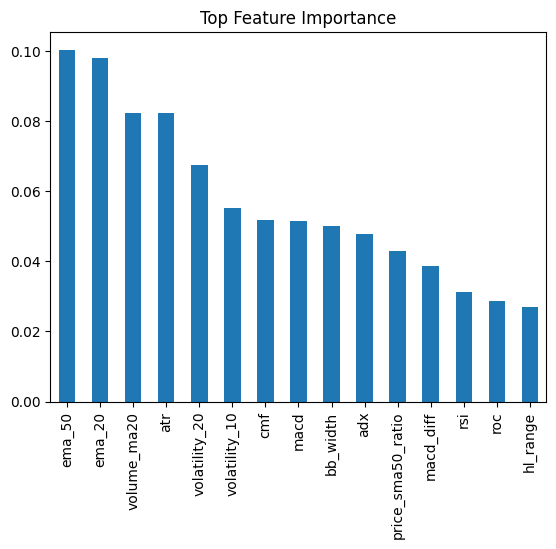

In [933]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

import matplotlib.pyplot as plt

importance.head(15).plot(kind="bar")
plt.title("Top Feature Importance")
plt.show()

In [934]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [935]:
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
#technical indicators are non-linear
#bro skipped all the extremee events

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        89
           0       0.68      1.00      0.81       866
           1       0.00      0.00      0.00       321

    accuracy                           0.68      1276
   macro avg       0.23      0.33      0.27      1276
weighted avg       0.46      0.68      0.55      1276

[[  0  89   0]
 [  0 866   0]
 [  0 321   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [936]:
#XGB Model
from xgboost import XGBClassifier
y_train_xgb = y_train+1
y_test_xgb = y_test+1
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_xgb)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = y_pred_xgb - 1

In [937]:
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

          -1       0.08      0.29      0.12        89
           0       0.68      0.73      0.70       866
           1       0.00      0.00      0.00       321

    accuracy                           0.52      1276
   macro avg       0.25      0.34      0.28      1276
weighted avg       0.47      0.52      0.49      1276

[[ 26  63   0]
 [230 636   0]
 [ 81 240   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [938]:
#Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.07      0.25      0.11        89
           0       0.70      0.78      0.74       866
           1       0.00      0.00      0.00       321

    accuracy                           0.55      1276
   macro avg       0.26      0.34      0.28      1276
weighted avg       0.48      0.55      0.51      1276

[[ 22  67   0]
 [188 678   0]
 [ 91 230   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [939]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train_dir, y_train_dir)

y_pred_dir = model.predict(X_test_dir)

print(classification_report(y_test_dir, y_pred_dir))
print(confusion_matrix(y_test_dir, y_pred_dir))

              precision    recall  f1-score   support

         0.0       0.36      0.84      0.50       426
         1.0       0.75      0.23      0.36       850

    accuracy                           0.44      1276
   macro avg       0.55      0.54      0.43      1276
weighted avg       0.62      0.44      0.40      1276

[[359  67]
 [652 198]]


In [ ]:
#Hist Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.08      0.34      0.12        89
           0       0.71      0.72      0.71       866
           1       0.00      0.00      0.00       321

    accuracy                           0.51      1276
   macro avg       0.26      0.35      0.28      1276
weighted avg       0.49      0.51      0.49      1276

[[ 30  59   0]
 [243 623   0]
 [122 199   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
#LightGBM model
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5864
[LightGBM] [Info] Number of data points in the train set: 5182, number of used features: 23
[LightGBM] [Info] Start training from score -2.221445
[LightGBM] [Info] Start training from score -0.353482
[LightGBM] [Info] Start training from score -1.664374
              precision    recall  f1-score   support

          -1       0.08      0.79      0.14        89
           0       0.73      0.32      0.44       866
           1       0.00      0.00      0.00       321

    accuracy                           0.27      1276
   macro avg       0.27      0.37      0.19      1276
weighted avg       0.50      0.27      0.31      1276

[[ 70  19   0]
 [592 274   0]
 [240  81   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
#catboost
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.07      0.33      0.12        89
           0       0.67      0.68      0.68       866
           1       0.00      0.00      0.00       321

    accuracy                           0.49      1276
   macro avg       0.25      0.34      0.27      1276
weighted avg       0.46      0.49      0.47      1276

[[ 29  60   0]
 [273 593   0]
 [ 86 235   0]]


/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gares/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave